In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter


In [ ]:
input_tif = "/isipd/projects/p_planetdw/data/lidar/05_results/Perma-X-2023-Till/DSM/WC_Inuvik_20230705_15cm_01_DSM.tif"
output_tif = "/isipd/projects/p_planetdw/data/lidar/05_results/Perma-X-2023-Till/DSM/Inuvik_DSM_2023_2m.tif"

target_resolution = 2  # metres

with rasterio.open(input_tif) as src:

    # Original resolution
    original_res_x = src.res[0]
    original_res_y = src.res[1]

    # Compute new dimensions
    scale_x = original_res_x / target_resolution
    scale_y = abs(original_res_y) / target_resolution

    new_width = int(src.width * scale_x)
    new_height = int(src.height * scale_y)

    # Resample
    data = src.read(
        out_shape=(
            src.count,
            new_height,
            new_width
        ),
        resampling=Resampling.average
    )

    # New transform
    new_transform = rasterio.Affine(
        target_resolution,
        src.transform.b,
        src.transform.c,
        src.transform.d,
        -target_resolution,
        src.transform.f
    )

    # Output profile
    profile = src.profile.copy()

    profile.update({
        "height": new_height,
        "width": new_width,
        "transform": new_transform,
        "compress": "lzw",
        "tiled": True,
        "blockxsize": 256,
        "blockysize": 256,
        "dtype": data.dtype
    })

    with rasterio.open(output_tif, "w", **profile) as dst:
        dst.write(data)

print("Done.")

Done.


In [130]:
macs= "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/MACS_Ortho_imgs/WC_Inuvik_20250727_15cm_01/Inuvik_2025DSM_2m.tif"
lidar = "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/results/Inuvik_2025/DSM/Inuvik_DSM_2m.tif"

output_path = "/isipd/projects/Response/GIS_RS_projects/Masterarbeit_Till_Weiss/outputs/plots/MacsVsLidar/"

In [131]:
with rasterio.open(macs) as src1:
    print("Macs")
    print("CRS:", src1.crs)
    print("Resolution:", src1.res)
    print("Bounds:", src1.bounds)
    print("Shape:", src1.shape)

with rasterio.open(lidar) as src2:
    print("\nLidar")
    print("CRS:", src2.crs)
    print("Resolution:", src2.res)
    print("Bounds:", src2.bounds)
    print("Shape:", src2.shape)

Macs
CRS: EPSG:32608
Resolution: (2.0002932254802723, 2.000069650008741)
Bounds: BoundingBox(left=547823.14515, bottom=7577862.17956, right=557714.59515, top=7589348.57956)
Shape: (5743, 4945)

Lidar
CRS: COMPD_CS["WGS 84 / UTM zone 8N + EGM2008 height",PROJCS["WGS 84 / UTM zone 8N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-135],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32608"]],VERT_CS["EGM2008 height",VERT_DATUM["EGM2008 geoid",2005,AUTHORITY["EPSG","1027"]],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Gravity-related h

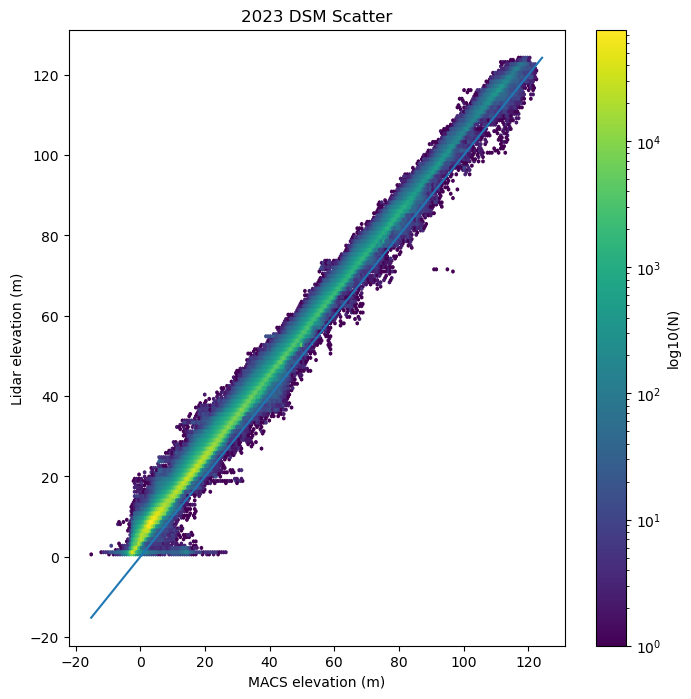

In [132]:
# Reference DSM
with rasterio.open(macs) as ref:
    dsm1 = ref.read(1)
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_shape = dsm1.shape

# DSM to align
with rasterio.open(lidar) as src:

    dsm2_resampled = np.empty(ref_shape, dtype=np.float32)

    reproject(
        source=rasterio.band(src, 1),
        destination=dsm2_resampled,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        resampling=Resampling.max
    )

# Create mask
mask = (
    np.isfinite(dsm1) &
    np.isfinite(dsm2_resampled) &
    (dsm1 > -1000) &
    (dsm2_resampled > -1000)
)

x = dsm1[mask]
y = dsm2_resampled[mask]

# Plot
plt.figure(figsize=(8,8))

plt.hexbin(x, y, gridsize=200, bins='log')

minval = min(x.min(), y.min())
maxval = max(x.max(), y.max())

plt.plot([minval, maxval], [minval, maxval])

plt.xlabel("MACS elevation (m)")
plt.ylabel("Lidar elevation (m)")
plt.title("2023 DSM Scatter")
plt.colorbar(label="log10(N)")

#plt.savefig(f"{output_path}2023_DSM_scatter_ICP_c1.png", dpi=300)

plt.show()


In [133]:
# Difference
ddsm = dsm2_resampled - dsm1

# Optional: mask extreme artefacts
ddsm = np.where(
    np.abs(ddsm) > 20,
    np.nan,
    ddsm
)

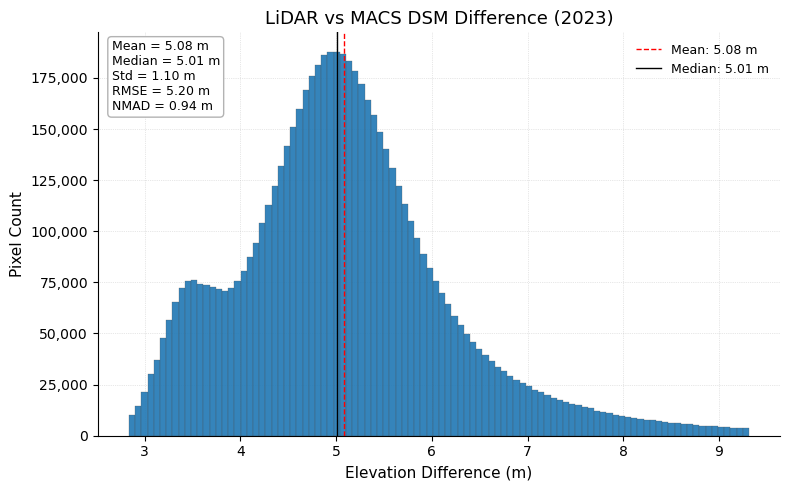

In [134]:
# -----------------------------------------
# DATA
# -----------------------------------------

vals = ddsm.flatten()   # replace with your array
vals = vals[np.isfinite(vals)]

# Optional clipping to remove extreme outliers
p1, p99 = np.percentile(vals, [1, 99])
vals = vals[(vals >= p1) & (vals <= p99)]

# -----------------------------------------
# STATISTICS
# -----------------------------------------

mean = np.mean(vals)
median = np.median(vals)
std = np.std(vals)
rmse = np.sqrt(np.mean(vals**2))
nmad = 1.4826 * np.median(np.abs(vals - median))

# -----------------------------------------
# FIGURE
# -----------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    vals,
    bins=100,
    linewidth=0.2,
    alpha=0.9,
    edgecolor='0.3'
)

# Mean and median lines
ax.axvline(mean, linestyle='--', color = 'red', linewidth=1, label=f'Mean: {mean:.2f} m')
ax.axvline(median, linestyle='-', color = 'k', linewidth=1, label=f'Median: {median:.2f} m')

# Labels
ax.set_title('LiDAR vs MACS DSM Difference (2023)', fontsize=13)
ax.set_xlabel('Elevation Difference (m)', fontsize=11)
ax.set_ylabel('Pixel Count', fontsize=11)

# Grid
ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.6)
ax.set_axisbelow(True)

# Clean axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Tick formatting
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{int(x):,}')
)

# Statistics box
stats = (
    f'Mean = {mean:.2f} m\n'
    f'Median = {median:.2f} m\n'
    f'Std = {std:.2f} m\n'
    f'RMSE = {rmse:.2f} m\n'
    f'NMAD = {nmad:.2f} m'
)

ax.text(
    0.02,
    0.98,
    stats,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',
    bbox=dict(
        facecolor='white',
        edgecolor='0.7',
        boxstyle='round'
    )
)

ax.legend(fontsize=9, frameon=False)

plt.tight_layout()

# Optional export
#plt.savefig(f"{output_path}/2023_DSM_difference_histogram_ICP_c1.png", dpi=300)

plt.show()

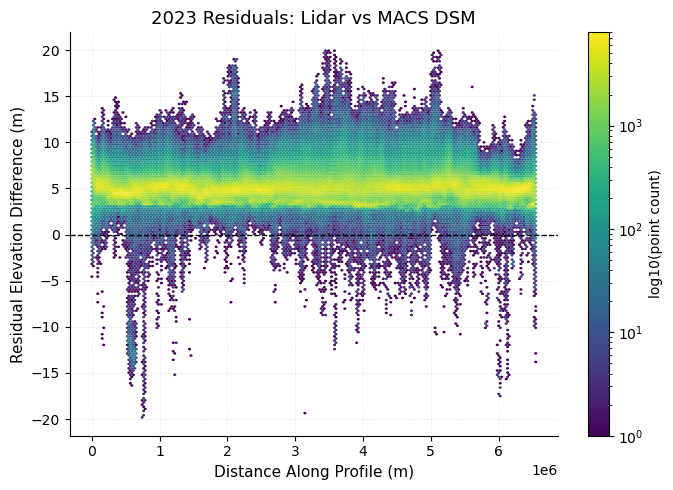

In [135]:
# Flatten for plotting
diff = ddsm.flatten()
diff = diff[np.isfinite(diff)]

# Example x values
# Replace with your actual distance/profile variable
x = np.arange(len(diff))

fig, ax = plt.subplots(figsize=(7, 5))

hb = ax.hexbin(
    x,
    diff,
    gridsize=150,
    bins='log',
    mincnt=1,
    linewidths=0
)

# Zero residual reference
ax.axhline(
    0,
    linestyle='--',
    linewidth=1,
    color='black'
)

# Labels
ax.set_xlabel('Distance Along Profile (m)', fontsize=11)
ax.set_ylabel('Residual Elevation Difference (m)', fontsize=11)

# Title
ax.set_title('2023 Residuals: Lidar vs MACS DSM', fontsize=13)

# Optional y-limits
# ax.set_ylim(-5, 5)

# Light grid
ax.grid(
    True,
    linestyle=':',
    linewidth=0.5,
    alpha=0.5
)

ax.set_axisbelow(True)

# Cleaner axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Colourbar
cbar = fig.colorbar(hb, ax=ax)
cbar.set_label('log10(point count)', fontsize=10)

# Tick size
ax.tick_params(axis='both', labelsize=10)

#plt.savefig(f"{output_path}2023_DSM_residuals_ICP_c1.png", dpi=300)

plt.tight_layout()
plt.show()

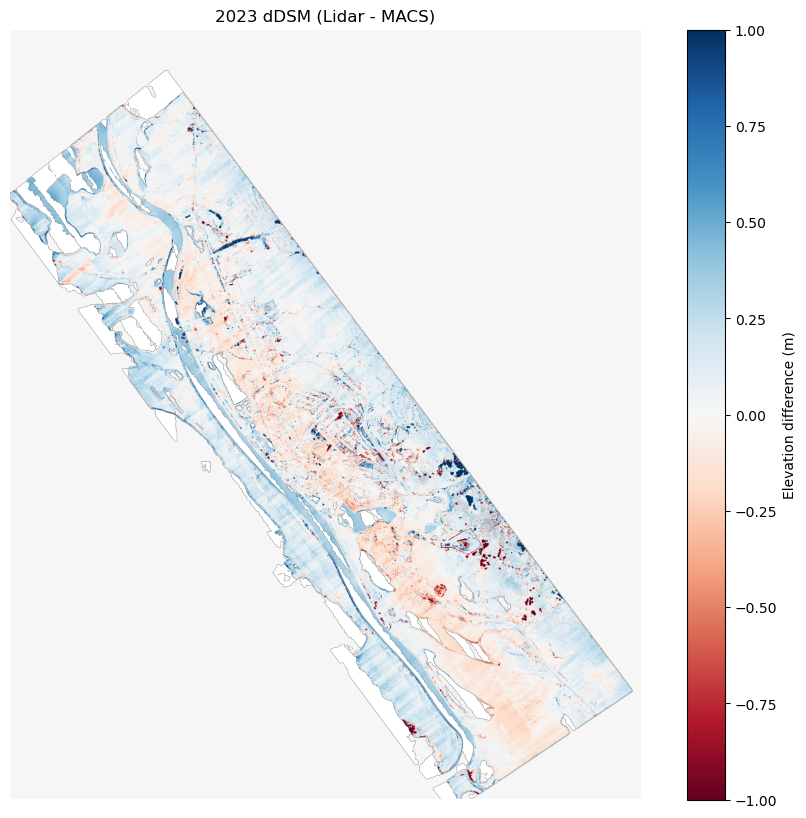

In [125]:
plt.figure(figsize=(12,10))

im = plt.imshow(
    ddsm,
    cmap="RdBu",
    vmin=-1,
    vmax=1
)

plt.colorbar(im, label="Elevation difference (m)")

plt.title("2023 dDSM (Lidar - MACS)")
plt.axis("off")
#plt.savefig(f"{output_path}2023_dDSM_ICP_c1.png", dpi=300)

plt.show()

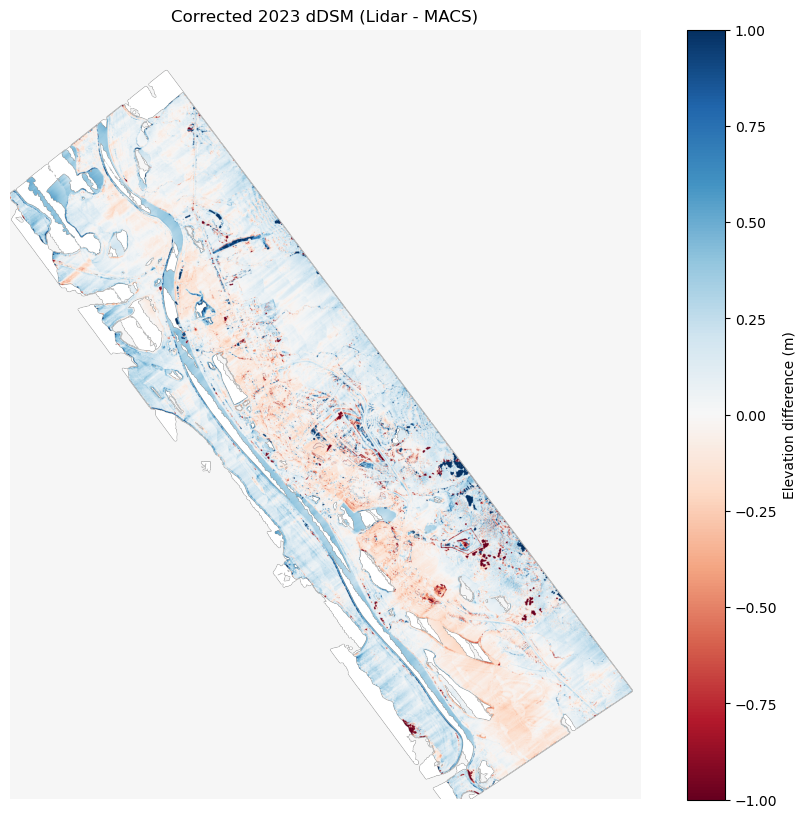

In [127]:
ddsm = dsm2_resampled - dsm1

ddsm = np.where(
    np.abs(ddsm) > 20,
    np.nan,
    ddsm
)
bias = np.nanmedian(ddsm)

ddsm_corr = ddsm - bias
# Optional: mask extreme artefacts
ddsm_corr = np.where(
    np.abs(ddsm_corr) > 20,
    np.nan,
    ddsm_corr
)

plt.figure(figsize=(12,10))

im = plt.imshow(
    ddsm_corr,
    cmap="RdBu",
    vmin=-1,
    vmax=1
)

plt.colorbar(im, label="Elevation difference (m)")

plt.title("Corrected 2023 dDSM (Lidar - MACS)")
plt.axis("off")

#plt.savefig(f"{output_path}2023_corrected_dDSM_ICP_c1.png", dpi=300)

plt.show()